## Business Problem

**Creating a model to predict whether the Gall Stone is present or not**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_excel('Gallstone.xlsx')
df

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,Body Mass Index (BMI),Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg),Hepatic Fat Accumulation (HFA),Glucose,Total Cholesterol (TC),Low Density Lipoprotein (LDL),High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,27.1,52.9,21.2,31.7,40.00,19.20,80.84,18.88,9,3.70,71.4,23.40,17.8,10.60,39.700000,0,102.0,250.0,175.0,40.0,134.0,20.0,22.0,87.0,0.820,112.470000,0.000,16.00,33.000000
1,0,47,0,1,0,0,0,0,176,94.5,30.5,43.1,19.5,23.6,45.00,32.80,67.20,16.68,15,3.20,60.3,38.80,31.0,18.40,32.700000,0,94.0,172.0,108.0,43.0,103.0,14.0,13.0,46.0,0.870,107.100000,0.000,14.40,25.000000
2,0,37,0,0,0,0,0,0,185,67.1,19.6,41.8,17.1,24.7,41.00,11.30,88.67,19.90,3,3.00,56.5,10.90,7.6,4.60,31.400000,0,94.0,166.0,111.0,40.0,60.0,15.0,14.0,72.0,0.770,118.250000,0.000,13.80,20.000000
3,0,38,0,0,0,0,0,0,171,68.6,23.5,39.5,16.6,22.9,42.00,19.20,80.76,17.28,6,2.80,52.6,6.70,13.2,8.20,28.800000,0,93.0,239.0,169.0,43.0,129.0,19.0,34.0,75.0,0.910,110.630000,0.000,16.60,15.600000
4,0,43,0,0,0,0,0,0,168,73.4,26.0,45.5,18.1,27.4,40.00,15.40,84.60,16.44,6,3.10,59.0,18.20,11.3,6.60,31.900000,0,92.0,259.0,115.0,50.0,206.0,16.0,30.0,103.0,0.840,110.970000,0.000,16.60,22.400000
5,0,23,0,1,0,0,0,0,178,74.1,23.4,46.1,17.9,28.2,39.00,14.40,85.56,17.10,2,3.20,60.2,6.30,10.7,6.20,32.200000,0,89.0,194.0,151.0,51.0,87.0,22.0,15.0,83.0,1.000,108.460000,0.000,18.60,18.800000
6,0,34,0,0,0,0,0,0,174,99.8,33.0,53.2,21.4,31.8,40.00,27.40,72.65,14.04,11,3.60,68.9,49.80,27.3,18.10,35.300000,2,93.0,166.0,106.0,40.0,105.0,17.0,23.0,48.0,0.980,103.700000,0.000,16.70,35.280000
7,0,51,0,1,0,0,0,0,175,95.5,31.2,51.6,20.9,30.7,41.00,24.90,75.08,16.39,13,3.50,68.2,41.70,23.8,15.10,36.900000,1,113.0,241.0,152.0,31.0,241.0,23.0,35.0,51.0,1.030,87.950000,0.000,16.80,27.220000
8,0,35,0,0,0,0,0,0,176,69.3,22.4,44.5,17.7,26.8,40.00,11.40,88.60,17.92,3,3.10,58.3,1.80,7.9,4.40,31.800000,0,94.0,155.0,89.0,50.0,63.0,21.0,9.0,51.0,1.020,98.290000,0.000,16.30,19.160000
9,0,43,0,0,0,0,0,0,176,75.7,24.4,39.4,17.1,22.3,43.00,24.30,75.69,18.12,9,2.90,54.4,11.20,18.4,10.40,30.800000,0,99.0,167.0,110.0,40.0,63.0,19.0,18.0,76.0,0.980,98.120000,0.050,15.00,28.000000


## Data Exploration

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                136 non-null    int64  
 1   Age                                             136 non-null    int64  
 2   Gender                                          136 non-null    int64  
 3   Comorbidity                                     136 non-null    int64  
 4   Coronary Artery Disease (CAD)                   136 non-null    int64  
 5   Hypothyroidism                                  136 non-null    int64  
 6   Hyperlipidemia                                  136 non-null    int64  
 7   Diabetes Mellitus (DM)                          136 non-null    int64  
 8   Height                                          136 non-null    int64  
 9   Weight                                     

In [4]:
df["Gallstone Status"].unique()

array([0, 1], dtype=int64)

In [5]:
df["Gallstone Status"].value_counts()

Gallstone Status
0    76
1    60
Name: count, dtype: int64

### Dropping unnecessary columns 

In [6]:
df = df.drop(['Age',
              'Height',
              'Weight',
              'Gender',
              'Extracellular Fluid/Total Body Water (ECF/TBW)',
              'Coronary Artery Disease (CAD)',
              'Hypothyroidism',   
              'Hyperlipidemia',       
              'Diabetes Mellitus (DM)'], axis=1)

## Variable Classification

In [7]:
continous = ['Body Mass Index (BMI)',
            'Total Body Water (TBW)',
            'Extracellular Water (ECW)',
            'Intracellular Water (ICW)',
            'Total Body Fat Ratio (TBFR) (%)',
            'Lean Mass (LM) (%)',
            'Body Protein Content (Protein) (%)',
            'Bone Mass (BM)',
            'Muscle Mass (MM)',
            'Obesity (%)',
            'Total Fat Content (TFC)',
            'Visceral Fat Area (VFA)',
            'Visceral Muscle Area (VMA) (Kg)',
            'Hepatic Fat Accumulation (HFA)',
            'Glucose',
            'Total Cholesterol (TC)',
            'Low Density Lipoprotein (LDL)',
            'High Density Lipoprotein (HDL)',
            'Triglyceride',
            'Aspartat Aminotransferaz (AST)',
            'Alanin Aminotransferaz (ALT)',
            'Alkaline Phosphatase (ALP)',
            'Creatinine',
            'Glomerular Filtration Rate (GFR)',
            'Hemoglobin (HGB)',
            'Vitamin D']

discrete_count = ['Visceral Fat Rating (VFR)']

categorical = ['Gallstone Status', 'Comorbidity']

## Exploratory Data Analysis

In [8]:
df[continous].describe()

,Body Mass Index (BMI),Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg),Hepatic Fat Accumulation (HFA),Glucose,Total Cholesterol (TC),Low Density Lipoprotein (LDL),High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),Hemoglobin (HGB),Vitamin D
count,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000
mean,27.229412,38.927206,16.322059,22.511765,27.226691,72.709412,16.032647,2.703309,51.909559,23.393382,20.992647,10.620882,29.450874,0.735294,96.207353,203.566176,127.290441,52.295588,115.663971,18.047794,19.125000,69.462500,0.765037,105.689907,14.299632,21.357812
std,4.289282,7.364253,2.831298,4.805276,7.950286,7.945878,1.764132,0.475714,9.877276,15.333280,7.718200,4.134137,4.523327,0.928841,7.746202,39.129690,34.236517,11.400668,54.208181,4.390174,7.239488,19.829069,0.162785,12.213754,1.718403,9.343601
min,17.400000,26.000000,11.000000,14.300000,10.900000,57.170000,12.090000,1.800000,32.800000,0.400000,6.900000,2.000000,18.900000,0.000000,82.000000,107.000000,35.000000,31.000000,23.000000,9.000000,3.000000,24.000000,0.460000,71.830000,9.400000,3.500000
25%,24.400000,33.350000,14.000000,18.675000,20.075000,65.822500,14.747500,2.300000,43.900000,11.350000,15.300000,7.975000,26.075000,0.000000,91.000000,173.000000,105.750000,44.000000,71.000000,15.000000,14.000000,55.750000,0.620000,99.225000,13.175000,15.000000
50%,27.150000,38.150000,16.350000,22.000000,27.600000,72.425000,15.865000,2.600000,50.750000,21.000000,20.700000,10.350000,29.600000,0.000000,95.000000,199.500000,126.000000,50.000000,105.000000,17.000000,18.000000,66.500000,0.730000,106.888333,14.225000,23.062500
75%,30.125000,44.425000,18.400000,25.800000,34.125000,79.487500,17.327500,3.100000,59.000000,32.777500,26.550000,13.405000,32.300000,2.000000,100.000000,231.000000,151.000000,60.250000,148.250000,21.000000,23.000000,80.250000,0.882500,113.690000,15.625000,28.173333
max,37.800000,57.400000,22.500000,35.000000,42.800000,89.150000,20.770000,3.800000,78.700000,72.000000,40.300000,21.630000,40.500000,3.000000,118.000000,309.000000,221.000000,79.000000,275.000000,30.000000,40.000000,122.000000,1.200000,132.000000,18.800000,46.000000


## Data Cleaning

In [10]:
df.isnull().sum()

Gallstone Status                      0
Comorbidity                           0
Body Mass Index (BMI)                 0
Total Body Water (TBW)                0
Extracellular Water (ECW)             0
Intracellular Water (ICW)             0
Total Body Fat Ratio (TBFR) (%)       0
Lean Mass (LM) (%)                    0
Body Protein Content (Protein) (%)    0
Visceral Fat Rating (VFR)             0
Bone Mass (BM)                        0
Muscle Mass (MM)                      0
Obesity (%)                           0
Total Fat Content (TFC)               0
Visceral Fat Area (VFA)               0
Visceral Muscle Area (VMA) (Kg)       0
Hepatic Fat Accumulation (HFA)        0
Glucose                               0
Total Cholesterol (TC)                0
Low Density Lipoprotein (LDL)         0
High Density Lipoprotein (HDL)        0
Triglyceride                          0
Aspartat Aminotransferaz (AST)        0
Alanin Aminotransferaz (ALT)          0
Alkaline Phosphatase (ALP)            0


In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().value_counts()

False    136
Name: count, dtype: int64

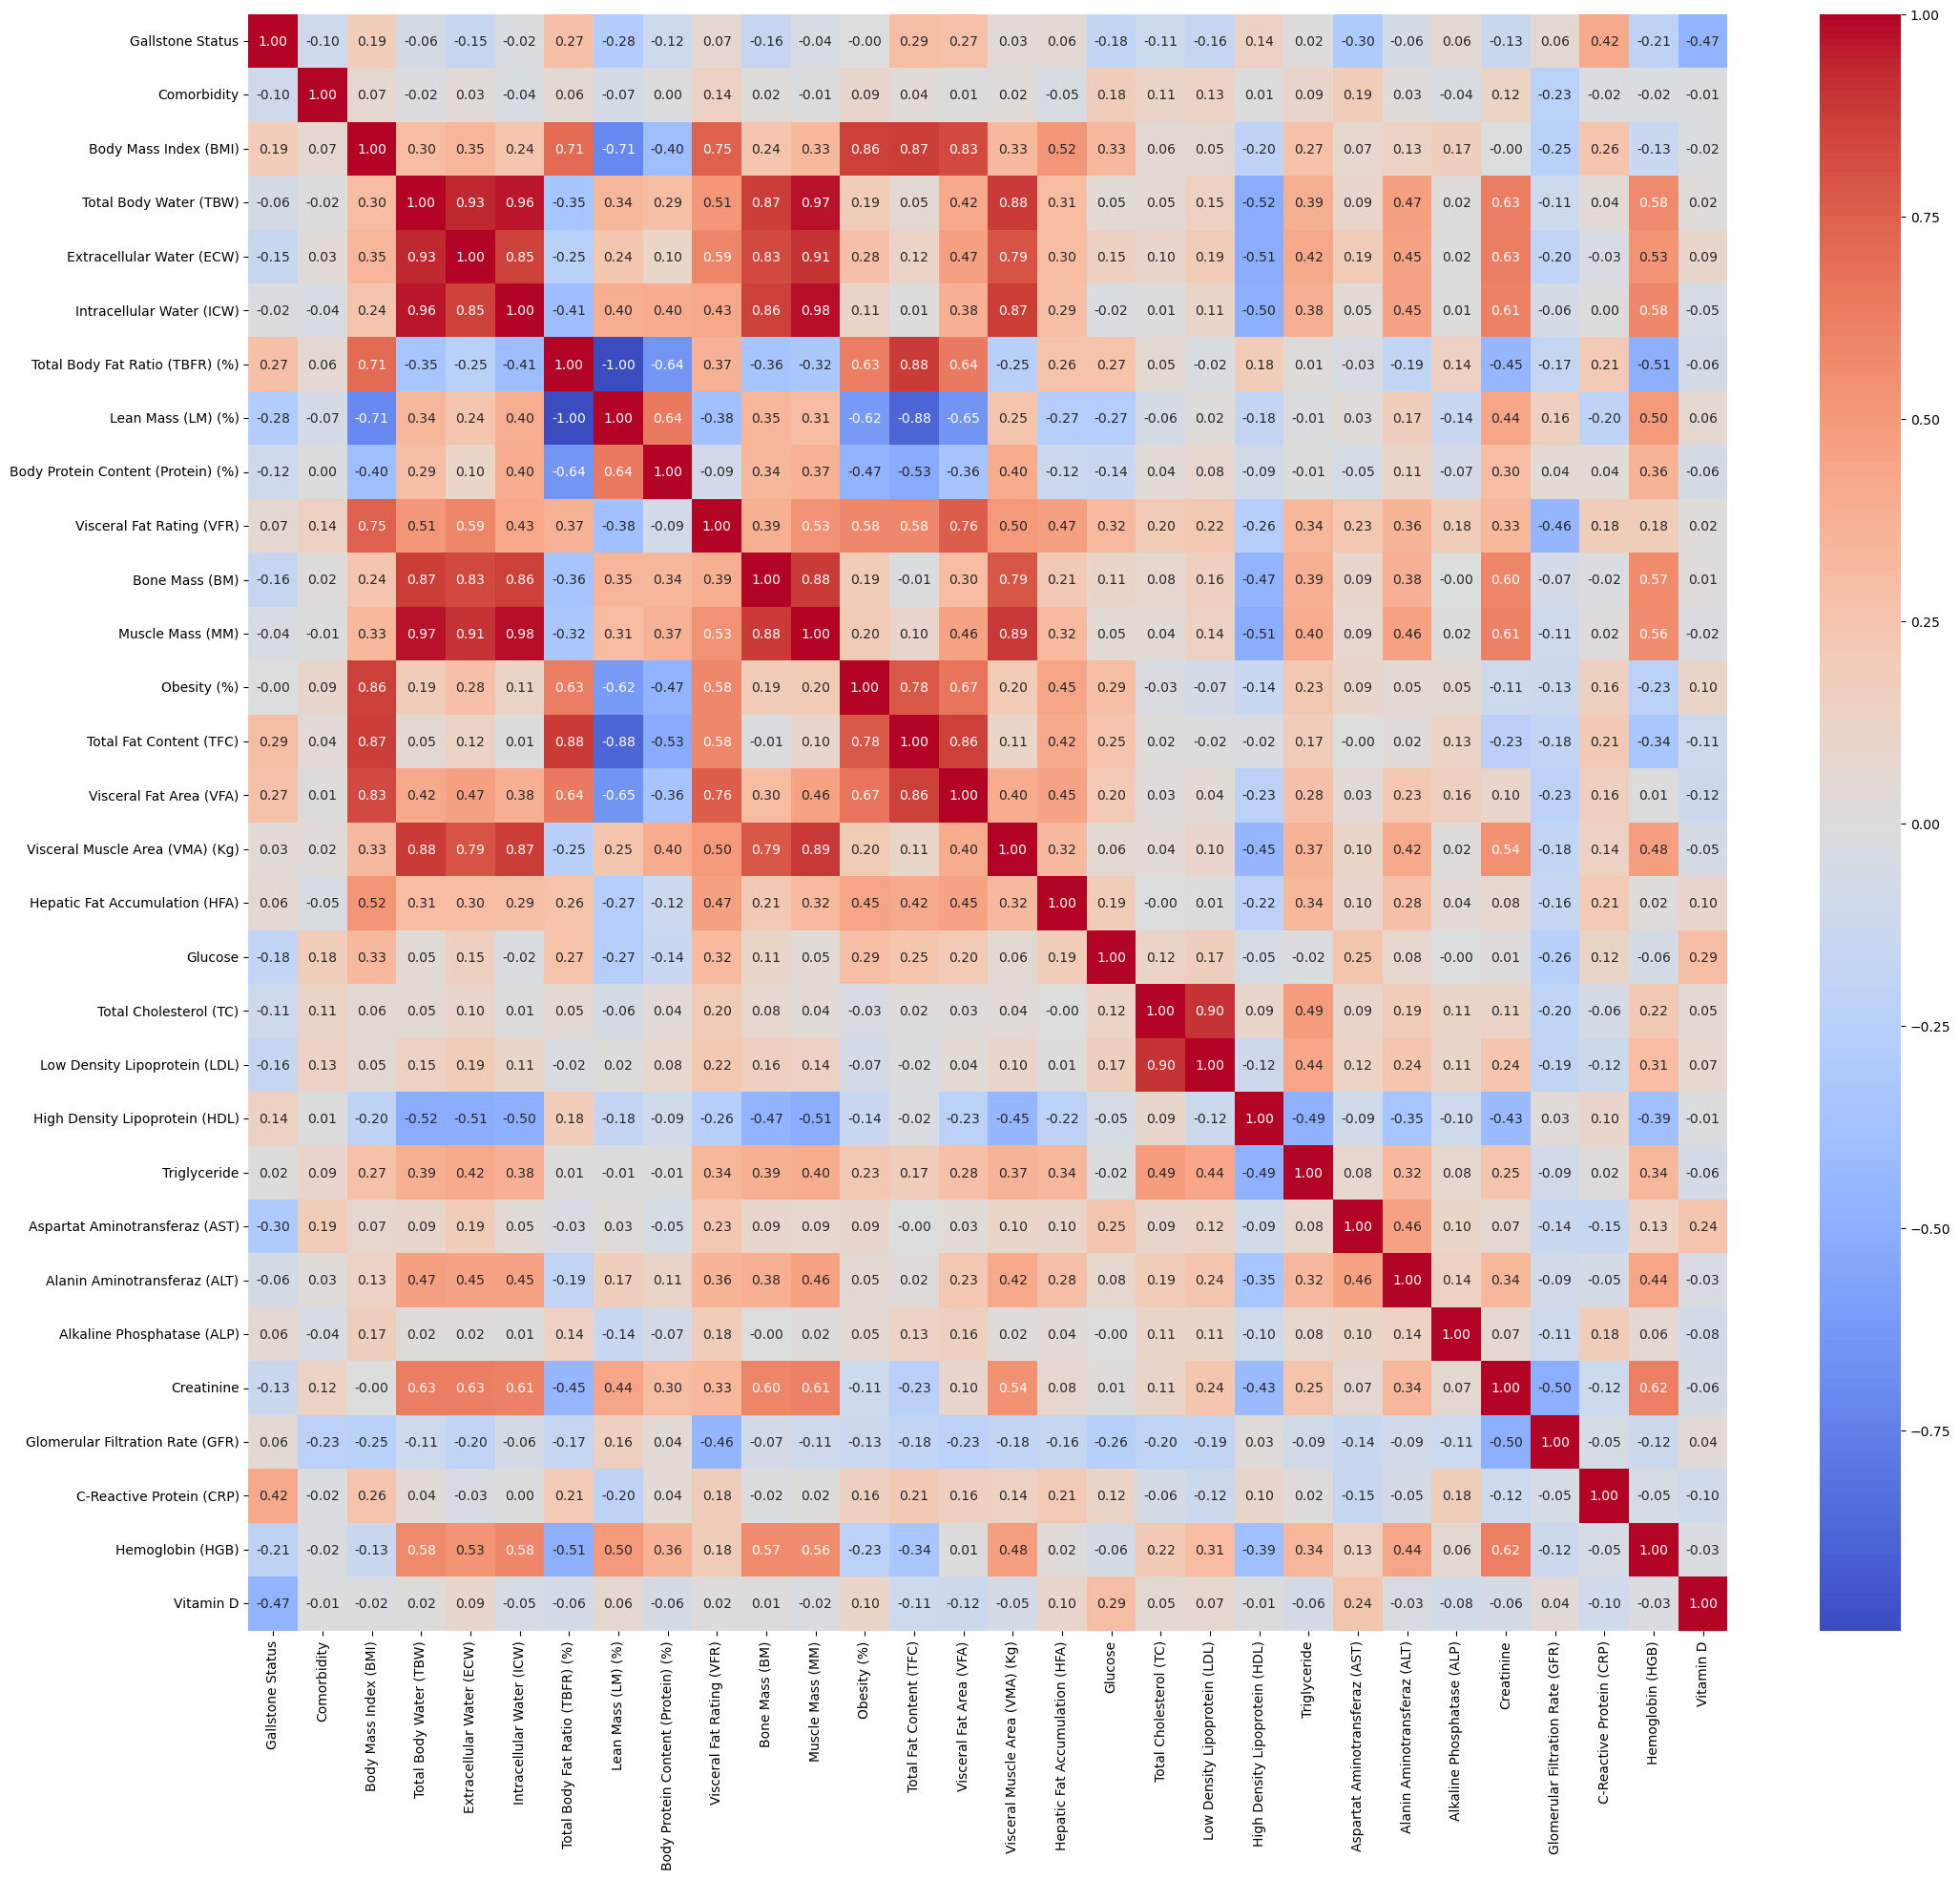

In [13]:
plt.figure(figsize=(25,22))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [14]:
df.corr()['Gallstone Status'].sort_values(ascending=False)*100

Gallstone Status                      100.000000
C-Reactive Protein (CRP)               41.753142
Total Fat Content (TFC)                29.298871
Total Body Fat Ratio (TBFR) (%)        27.487740
Visceral Fat Area (VFA)                27.247732
Body Mass Index (BMI)                  18.759273
High Density Lipoprotein (HDL)         14.271314
Visceral Fat Rating (VFR)               6.688126
Alkaline Phosphatase (ALP)              6.232755
Hepatic Fat Accumulation (HFA)          6.212607
Glomerular Filtration Rate (GFR)        5.836824
Visceral Muscle Area (VMA) (Kg)         3.439234
Triglyceride                            1.657815
Obesity (%)                            -0.281399
Intracellular Water (ICW)              -1.517466
Muscle Mass (MM)                       -4.359979
Total Body Water (TBW)                 -5.597295
Alanin Aminotransferaz (ALT)           -5.851365
Comorbidity                           -10.176369
Total Cholesterol (TC)                -11.090544
Body Protein Content

### Dropping columns with low correlation

In [15]:
cols_to_drop = ['Visceral Muscle Area (VMA) (Kg)',
                'Triglyceride',
                'Obesity (%)',
                'Intracellular Water (ICW)',
                'Muscle Mass (MM)']

df = df.drop(cols_to_drop, axis=1)

continous = [col for col in continous if col not in cols_to_drop]

In [16]:
df_corr = pd.DataFrame(df.corr()['Gallstone Status'].sort_values(ascending=False).reset_index())
df_corr.columns = ['Feature','corr']
df_corr.head(15)

,Feature,corr
0,Gallstone Status,1.000000
1,C-Reactive Protein (CRP),0.417531
2,Total Fat Content (TFC),0.292989
3,Total Body Fat Ratio (TBFR) (%),0.274877
4,Visceral Fat Area (VFA),0.272477
5,Body Mass Index (BMI),0.187593
6,High Density Lipoprotein (HDL),0.142713
7,Visceral Fat Rating (VFR),0.066881
8,Alkaline Phosphatase (ALP),0.062328
9,Hepatic Fat Accumulation (HFA),0.062126


## Data Wrangling
---> The dataset is already numerical so encoding is not required**

In [17]:
df[continous].skew()

Body Mass Index (BMI)                 0.046752
Total Body Water (TBW)                0.393302
Extracellular Water (ECW)             0.149948
Total Body Fat Ratio (TBFR) (%)      -0.112115
Lean Mass (LM) (%)                    0.128595
Body Protein Content (Protein) (%)    0.126683
Bone Mass (BM)                        0.296974
Total Fat Content (TFC)               0.199616
Visceral Fat Area (VFA)               0.199793
Hepatic Fat Accumulation (HFA)        0.778802
Glucose                               0.726150
Total Cholesterol (TC)                0.222093
Low Density Lipoprotein (LDL)         0.204545
High Density Lipoprotein (HDL)        0.490126
Aspartat Aminotransferaz (AST)        0.462243
Alanin Aminotransferaz (ALT)          0.644278
Alkaline Phosphatase (ALP)            0.378910
Creatinine                            0.480704
Glomerular Filtration Rate (GFR)     -0.496956
Hemoglobin (HGB)                     -0.066740
Vitamin D                            -0.104106
dtype: float6

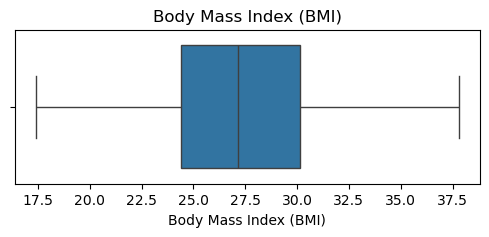

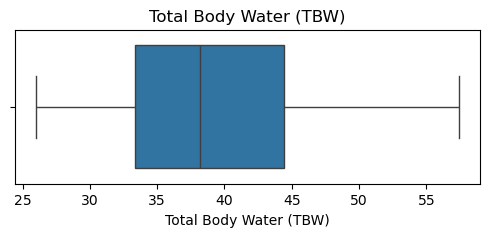

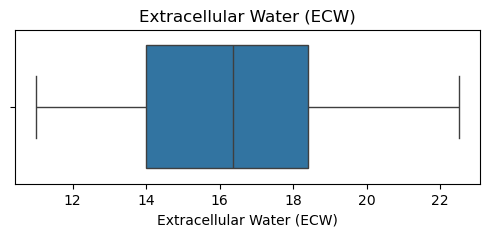

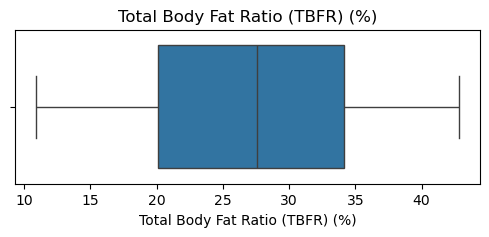

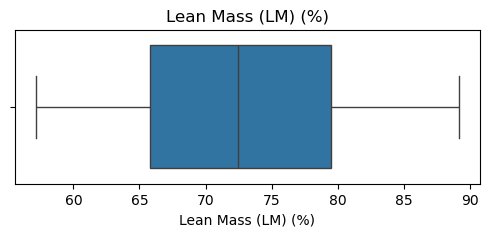

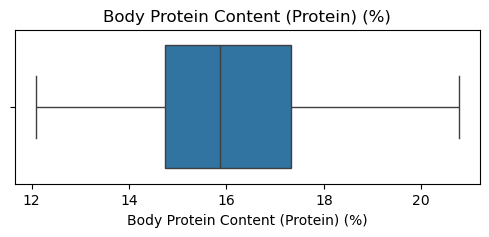

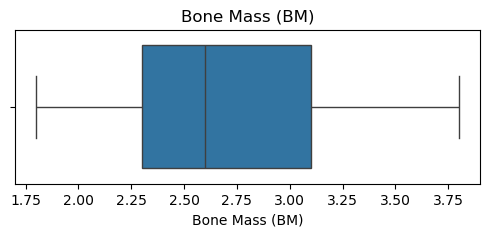

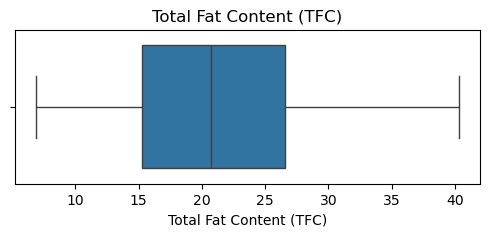

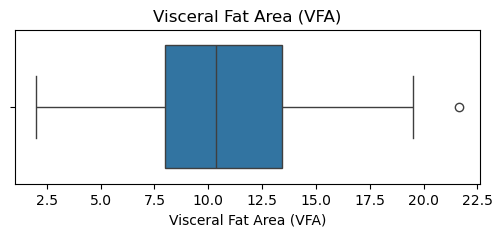

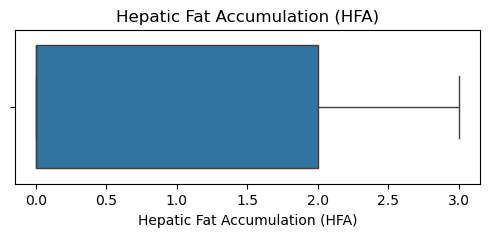

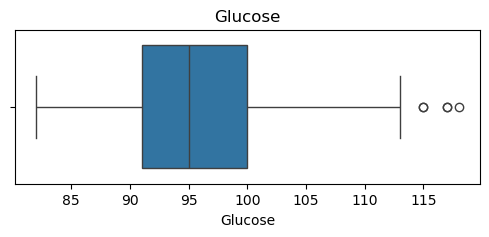

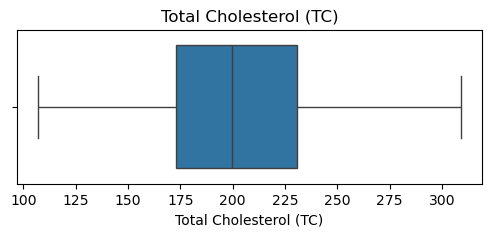

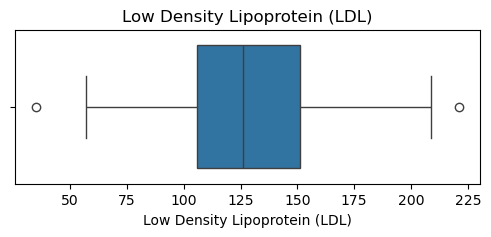

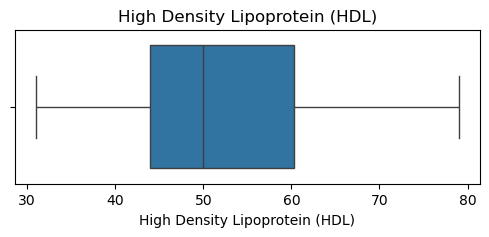

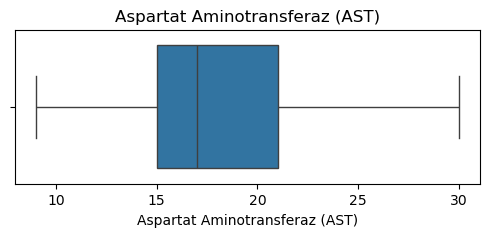

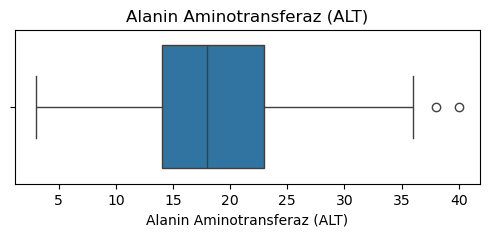

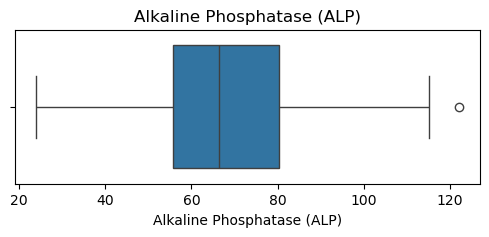

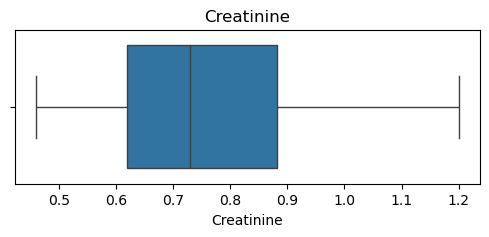

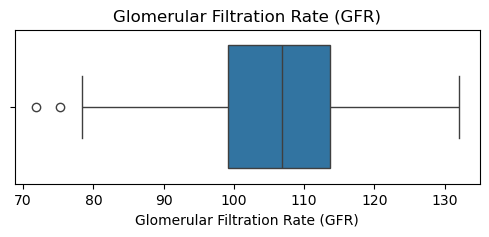

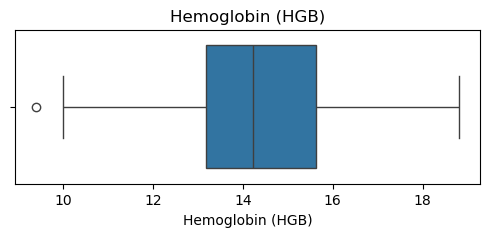

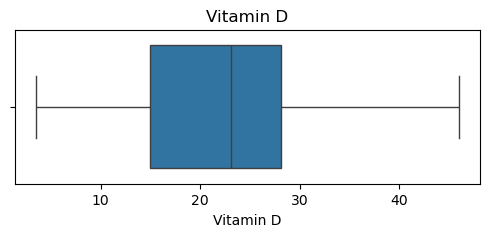

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in continous:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [19]:
df.shape

(136, 25)

cols = ["Age",
        "Weight",
        "Body Mass Index (BMI)",
        "Obesity (%)",
        "Visceral Fat Area (VFA)",
        "Glucose",
        "Total Cholesterol (TC)",
        "Low Density Lipoprotein (LDL)",
        "High Density Lipoprotein (HDL)",
        "Triglyceride",
        "Aspartat Aminotransferaz (AST)",
        "Alanin Aminotransferaz (ALT)",
        "Alkaline Phosphatase (ALP)",
        "Vitamin D"]

#calculate Q1
Q1=df[cols].quantile(0.25)
print("Q1:",Q1)

#calculate Q3
Q3=df[cols].quantile(0.75)
print("Q3:",Q3)

#calculate IQR
IQR = Q3 - Q1
print("IQR:",IQR)

#Calculate lower limit of outlier
lower_limit = Q1 - (IQR * 1.5)
print("lower_limit:",lower_limit)

#Calculate upper limit of outlier
upper_limit = Q3 + (IQR * 1.5)
print("upper_limit:",upper_limit)

df['Age'] = df['Age'].clip(lower=11.625000, upper=82.625000)
df['Weight'] = df['Weight'].clip(lower=37.012500, upper=123.912500)
df['Body Mass Index (BMI)'] = df['Body Mass Index (BMI)'].clip(lower=15.437500, upper=41.737500)
df['Obesity (%)'] = df['Obesity (%)'].clip(lower=-2.403028, upper=2.511981)
df['Visceral Fat Area (VFA)'] = df['Visceral Fat Area (VFA)'].clip(lower=-2.560603, upper=2.562048)
df['Glucose'] = df['Glucose'].clip(lower=-2.392704, upper=2.415657)
df['Total Cholesterol (TC)'] = df['Total Cholesterol (TC)'].clip(lower=81.125000, upper=324.125000)
df['Low Density Lipoprotein (LDL)'] = df['Low Density Lipoprotein (LDL)'].clip(lower=26.000000, upper=226.000000)
df['High Density Lipoprotein (HDL)'] = df['High Density Lipoprotein (HDL)'].clip(lower=-2.534666, upper=2.578580)
df['Triglyceride'] = df['Triglyceride'].clip(lower=-2.504435, upper=2.394460)
df['Aspartat Aminotransferaz (AST)'] = df['Aspartat Aminotransferaz (AST)'].clip(lower=-2.415600, upper=2.406174)
df['Alanin Aminotransferaz (ALT)'] = df['Alanin Aminotransferaz (ALT)'].clip(lower=-2.529696, upper=2.550926)
df['Alkaline Phosphatase (ALP)'] = df['Alkaline Phosphatase (ALP)'].clip(lower=16.000000, upper=128.000000)
df['Vitamin D'] = df['Vitamin D'].clip(lower=-8.937500, upper=50.162500)
df

In [20]:
# continuous columns
cols = [ 'Visceral Fat Area (VFA)',
         'Glucose',
         'Low Density Lipoprotein (LDL)',
         'Alanin Aminotransferaz (ALT)',
         'Alkaline Phosphatase (ALP)',
         'Glomerular Filtration Rate (GFR)',
         'Hemoglobin (HGB)',]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.clip(df[col], lower, upper)

### Feature Selection (X & y)

In [21]:
X = df.drop('Gallstone Status', axis=1)
y = df['Gallstone Status']

**Choosing best random state number**

In [165]:
Train = []
Test = []
CV = []

for i in range(0, 150):
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    from sklearn.linear_model import LogisticRegression
    log_default = LogisticRegression()
    log_default.fit(X_train, y_train)

    ypred_train = log_default.predict(X_train)
    ypred_test = log_default.predict(X_test)

    from sklearn.metrics import accuracy_score
    Train.append(accuracy_score(y_train, ypred_train))
    Test.append(accuracy_score(y_test, ypred_test))
    
    from sklearn.model_selection import cross_val_score
    CV.append(cross_val_score(log_default, X_train, y_train, cv=5, scoring="accuracy").mean())

em = pd.DataFrame({"Train":Train, "Test":Test, "CV":CV})
gm = em[(abs(em['Train'] - em['Test']) <= 0.05) & 
        (abs(em['Test'] - em['CV']) <= 0.05)] 
rs = gm[gm["CV"] == gm["CV"].max()].index.to_list()[0]
print("best random_state number:", rs)

best random_state number: 97


### Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 97)

## Modelling
**Logistic Regression**

In [23]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()

log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
log_reg.intercept_

array([0.00438034])

In [25]:
log_reg.coef_

array([[ 0.02234196,  0.22470764,  0.07725827, -0.72233109, -0.10411591,
         0.16708302, -0.09994684,  0.0445466 , -0.15486611, -0.00969299,
         0.51121467,  0.05672171, -0.05318668, -0.01246895,  0.01513507,
         0.03057011, -0.22985027,  0.13986472, -0.0112154 ,  0.04523778,
         0.05719399,  1.51016178, -0.58444422, -0.1475613 ]])

In [26]:
X_train.shape

(108, 24)

In [27]:
y_train.shape

(108,)

In [28]:
#prediction
ypred_train = log_reg.predict(X_train)

#train Accuracy
from sklearn.metrics import accuracy_score
print("Train accuracy:", accuracy_score(y_train, ypred_train)*100)

#Cross Validation Score
from sklearn.model_selection import cross_val_score
print("CV Score:", cross_val_score(log_reg, X_train, y_train, cv=5, scoring="accuracy").mean()*100)

#prediction
ypred_test = log_reg.predict(X_test)

#accuracy
print("Test accuracy:", accuracy_score(y_test, ypred_test)*100)

Train accuracy: 85.18518518518519
CV Score: 80.73593073593074
Test accuracy: 82.14285714285714


In [29]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, ypred_test))

[[14  0]
 [ 5  9]]


In [30]:
from sklearn.metrics import classification_report
print(classification_report(y_test, ypred_test))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85        14
           1       1.00      0.64      0.78        14

    accuracy                           0.82        28
   macro avg       0.87      0.82      0.82        28
weighted avg       0.87      0.82      0.82        28

